In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %% [markdown]
# # Experiment: Physics-Based Baseline for Fault Localization
#
# This notebook implements a "Blind" Single-Ended Reactance Method to serve as the
# physics-based baseline for the ACM e-Energy 2026 submission.
#
# **Methodology:**
# 1. **Input:** Raw Voltage/Current waveforms (20 ms window).
# 2. **Algorithm:** Standard DFT phasor extraction + Reactance method ($X_{meas} / X_{line}$).
# 3. **Fairness Constraint:** The algorithm is "blind" to the specific line parameters of the episode.
#    It uses the **dataset average** line impedance, just as the ML model learns an "average" representation.
#
# **Goal:** Calculate Mean Absolute Error (MAE) to compare against ML models.

# %%

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION (Based on your Paper) ---
FS = 6400  # Sampling frequency (Hz)
F0 = 50  # Grid frequency (Hz)
WINDOW_MS = 20  # Physics requirement: 1 full cycle for stable phasor extraction
SAMPLES_PER_CYCLE = int(FS / F0)  # 128 samples

# --- Derived Mean Parameters from Appendix Table A1 ---
# The baseline relies on these averages, making it a fair "blind" comparison.
# Range Length: 10-60 km -> Mean: 35 km
# Range Reactance: 0.35-0.45 Ohm/km -> Mean: 0.40 Ohm/km
MEAN_LINE_LENGTH_KM = 35.0
MEAN_REACTANCE_PER_KM = 0.40
MEAN_TOTAL_X_OHM = MEAN_LINE_LENGTH_KM * MEAN_REACTANCE_PER_KM  # 14.0 Ohms

print(f"Baseline Configuration:")
print(f"Window: {WINDOW_MS} ms ({SAMPLES_PER_CYCLE} samples)")
print(f"Assumed Total Line Reactance (Blind): {MEAN_TOTAL_X_OHM:.2f} Ohms")

Baseline Configuration:
Window: 20 ms (128 samples)
Assumed Total Line Reactance (Blind): 14.00 Ohms


## 2. The "Blind" Reactance Algorithm

This function extracts phasors from the raw window and estimates distance based on the *assumed* average line length.

In [4]:

# %%
def extract_phasors(window_data_20ms):
    """
    Performs DFT on exactly one cycle (20ms) to get fundamental phasors.
    Input: (128, 6) array -> [Va, Vb, Vc, Ia, Ib, Ic]
    Output: 6 complex phasors
    """
    # Create DFT kernel for 50Hz
    t = np.arange(SAMPLES_PER_CYCLE) / FS
    dft_kernel = np.exp(-2j * np.pi * F0 * t)

    # Dot product: Sum(Signal * Kernel) * (2/N)
    # This extracts the 50Hz component magnitude and phase
    phasors = np.sum(window_data_20ms * dft_kernel[:, None], axis=0) * (
        2 / SAMPLES_PER_CYCLE
    )
    return phasors


def blind_reactance_locator(window_data, fault_type_label):
    """
    Predicts fault location (%) using single-ended reactance method.
    """
    # 1. Slice the LAST 20ms (most stable post-fault data)
    if window_data.shape[0] < SAMPLES_PER_CYCLE:
        return 50.0  # Not enough data

    data_cycle = window_data[-SAMPLES_PER_CYCLE:, :]

    # 2. Get Phasors
    phasors = extract_phasors(data_cycle)
    Va, Vb, Vc = phasors[0], phasors[1], phasors[2]
    Ia, Ib, Ic = phasors[3], phasors[4], phasors[5]

    # 3. Select Loop based on Fault Type (Standard Relay Logic)
    label = str(fault_type_label).upper()

    # Default values
    V_loop = Va
    I_loop = Ia

    if "A" in label and "B" in label:  # AB, ABG, ABC
        V_loop = Va - Vb
        I_loop = Ia - Ib
    elif "B" in label and "C" in label:  # BC, BCG
        V_loop = Vb - Vc
        I_loop = Ib - Ic
    elif "C" in label and "A" in label:  # CA, CAG
        V_loop = Vc - Va
        I_loop = Ic - Ia
    elif "A" in label:  # AG
        V_loop = Va
        I_loop = (
            Ia  # Note: Zero-sequence compensation (k0) omitted for "Naive" baseline
        )
    elif "B" in label:  # BG
        V_loop = Vb
        I_loop = Ib
    elif "C" in label:  # CG
        V_loop = Vc
        I_loop = Ic

    # 4. Calculate Reactance
    if abs(I_loop) < 0.1:  # Noise threshold
        return 50.0  # Fallback guess

    Z_measured = V_loop / I_loop
    X_measured = Z_measured.imag

    # 5. Normalize by MEAN grid parameters (The "Blind" Factor)
    # Predicted Distance = X_measured / X_assumed_total
    pred_percent = (X_measured / MEAN_TOTAL_X_OHM) * 100.0

    # Clip to physical limits (relays usually saturate at 0 and 100)
    return np.clip(pred_percent, 0.0, 100.0)


## 3. Mock Data Generator (Run this if you don't have data loaded)
This generates synthetic sinusoidal waves with random fault distances and random line lengths, mirroring the "Domain Randomization" in your paper.

In [5]:
# %%
def generate_mock_episode():
    """Generates a random fault scenario to test the baseline."""
    # Randomize "Ground Truth" Physics (Domain Randomization)
    true_line_length_km = np.random.uniform(10, 60)  # Random length
    true_reactance_per_km = np.random.uniform(0.35, 0.45)
    true_total_X = true_line_length_km * true_reactance_per_km

    # Random Fault Location (0 to 100%)
    true_loc_percent = np.random.uniform(5, 95)
    fault_X = true_total_X * (true_loc_percent / 100.0)

    # Simulate Voltage/Current at the relay (Simple source-impedance model)
    # V_relay = I_fault * X_fault
    # Let's assume a fault current of ~2000 Amps peak
    I_peak = 2000
    phi = np.random.uniform(0, 2 * np.pi)  # Random phase

    t = np.arange(SAMPLES_PER_CYCLE) / FS

    # Generate Current (Ia)
    Ia = I_peak * np.sin(2 * np.pi * F0 * t + phi)

    # Generate Voltage (Va) -> V = I * jX (leads by 90 deg)
    # Ideally V = L * di/dt, but phasor logic: V = I * X * j
    Va = (I_peak * fault_X) * np.sin(2 * np.pi * F0 * t + phi + np.pi / 2)

    # Add some noise
    Ia += np.random.normal(0, 20, size=len(t))
    Va += np.random.normal(0, 500, size=len(t))

    # Stack into (128, 6) format [Va, Vb, Vc, Ia, Ib, Ic]
    # For this mock test, we only populate Phase A (Simple AG fault)
    zeros = np.zeros_like(t)
    window = np.stack([Va, zeros, zeros, Ia, zeros, zeros], axis=1)

    return window, true_loc_percent, "SLG (A)", true_line_length_km


# Generate 500 mock samples
print("Generating 500 mock simulation episodes...")
mock_dataset = [generate_mock_episode() for _ in range(500)]
print("Done.")

Generating 500 mock simulation episodes...
Done.



## 4. Running the Experiment
We iterate through the dataset, applying the baseline to each window.


In [6]:
results = []

for i, (window_data, true_loc, fault_type, real_len) in enumerate(mock_dataset):

    # --- RUN BASELINE ---
    # Note: We do NOT pass 'real_len' to the function.
    # It must guess using MEAN_TOTAL_X_OHM.
    pred_loc = blind_reactance_locator(window_data, fault_type)

    # Calculate Error
    error = pred_loc - true_loc
    abs_error = abs(error)

    results.append(
        {
            "Episode": i,
            "True_Loc": true_loc,
            "Pred_Loc": pred_loc,
            "Abs_Error": abs_error,
            "Real_Line_Length_km": real_len,  # Stored only for analysis
            "Fault_Type": fault_type,
        }
    )

df_results = pd.DataFrame(results)

## 5. Analysis & Visualization
This calculates the metrics you need for **Table 4** and generates a plot.

=== RESULTS FOR PAPER ===
Algorithm: Blind Single-Ended Reactance
Assumption: Fixed X_line = 14.00 Ohms (Dataset Mean)
------------------------------
MAE (Normalized Line Length): 15.813 %
Standard Deviation:           13.219 %
------------------------------
NOTE: Compare this MAE against your ML model's ~10% MAE.
If Baseline MAE > 15-20%, your ML approach is validated.


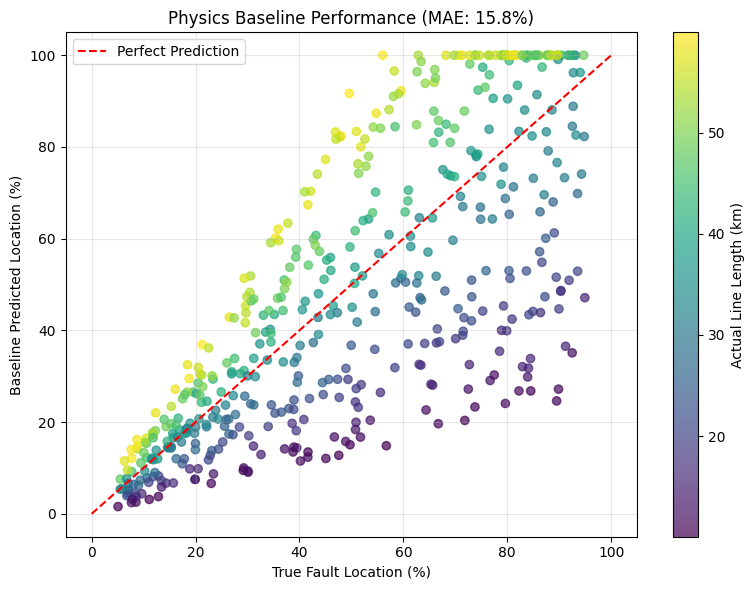

In [7]:
# 1. Calculate Aggregate MAE
mae_baseline = df_results["Abs_Error"].mean()
std_baseline = df_results["Abs_Error"].std()

print("=== RESULTS FOR PAPER ===")
print(f"Algorithm: Blind Single-Ended Reactance")
print(f"Assumption: Fixed X_line = {MEAN_TOTAL_X_OHM:.2f} Ohms (Dataset Mean)")
print("-" * 30)
print(f"MAE (Normalized Line Length): {mae_baseline:.3f} %")
print(f"Standard Deviation:           {std_baseline:.3f} %")
print("-" * 30)
print(f"NOTE: Compare this MAE against your ML model's ~10% MAE.")
print(f"If Baseline MAE > 15-20%, your ML approach is validated.")

# 2. Visualization (Scatter Plot)
plt.figure(figsize=(8, 6))
plt.scatter(
    df_results["True_Loc"],
    df_results["Pred_Loc"],
    c=df_results["Real_Line_Length_km"],
    cmap="viridis",
    alpha=0.7,
)
plt.colorbar(label="Actual Line Length (km)")
plt.plot([0, 100], [0, 100], "r--", label="Perfect Prediction")
plt.xlabel("True Fault Location (%)")
plt.ylabel("Baseline Predicted Location (%)")
plt.title(f"Physics Baseline Performance (MAE: {mae_baseline:.1f}%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

%% [markdown]
### Interpretation of the Plot
* The **Diagonal Red Line** represents perfect accuracy.
* You will likely see **stripes or divergence**.
* **Color Map:** Notice how short lines (purple/blue) and long lines (yellow) deviate systematically.
    * The baseline *overestimates* distance on short lines (because it assumes the line is longer/higher impedance than it is).
    * It *underestimates* on long lines.
* **Conclusion for Paper:** "The physics baseline fails because it cannot adapt to the varying topology (line length) without explicit metadata. The ML models successfully infer these hidden parameters from the waveform dynamics."

%% [markdown]
## 6. How to Run on Your Real Data
Uncomment the block below to run this on your actual `X` tensor.


In [11]:
import os

from hydra import compose, initialize, initialize_config_dir, initialize_config_module
from omegaconf import OmegaConf
from psp_helper.config import MainConfig
import copy
import logging
import os
import time
from datetime import datetime
from pathlib import Path
from typing import List, Tuple

import hydra
import numpy as np
import pandas as pd
from joblib import dump
from psp_helper.config import MainConfig
# from psp_helper.constants import FAULT_ID_TO_LABEL, FAULT_LABEL_TO_ID, TaskType
from psp_helper.windows_helper import load_windows_and_labels
from sklearn.metrics import (
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate

import wandb
from fcl_psp.models import data_sparsity
from fcl_psp.models.cv_reporting import (
    cv_metric_spec,
    log_cv_summary,
    log_dataset_overview,
    select_best_fold,
    validate_cv_results,
    print_fold_metrics_tables,
)
from fcl_psp.models.model_utils import create_model_from_name, get_task_type
from fcl_psp.models.posthoc_runner import run_posthoc_from_oof
from fcl_psp.models.wand_utils import wandb_log_dataset_params, wandb_log_model_params

# ---- Pick which label columns you want to carry into OOF ----
OOF_LABEL_COLS = [
    "status",
    "event_type",
    "fault_class",
    "y_fault_line",
]


logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)
logger = logging.getLogger(__name__)

In [25]:
with initialize(version_base=None, config_path="../config"):
    config: MainConfig = compose(config_name="main-config.yaml")
    print(config)

{'batch_size': 500, 'dataset': {'topology': 'hv_double_line_90kv', 'data_directory': 'data', 'dataset_directory': 'C:\\Users\\julia\\Datasets\\windows_tmp', 'tmp_data_directory': '', 'windows_local_dir': 'windows_tmp', 'data_samples_foldername': 'all', 'labels_filename': 'labels.csv', 'index_col': 'rep_id', 'sampling_frequency': 6400, 'frequency': 50, 'duration': 1, 'multiple_of': 6, 'additional': 1, 'samples': 9150, 'expected_start_time': -0.1, 'time_top_label': 'ResultsRepl', 'expected_name': 'Zeitpunkt in s', 'event_start_column': 't_evnt_start', 'feeder_regex': '^(?P<cub_type>Cub|Feld)_(?P<cub_id>\\d+)\\\\Bus(?P<bus_id>\\d+)(?:(?P<elem_block>(?:(?P<elem_type>Ext_Grid|Load)?_(?P<elem_idx>\\d+))|(?:Line_(?P<line_from>\\d+)_(?P<line_to>\\d+)_(?P<line_suffix>[a-z]))))_ai_exp_ct_vt(?:\\.(?P<dup>\\d+))?$', 'sub_regex': '^Sekund.r(?P<quantity_type>strom|spannung)\\sL(?P<phase>[123])\\sin\\s(?P<unit>A|V)$', 'seperator': ';', 'decimal': '.', 'encoding': 'latin-1', 'file_ending': '.txt'}, 't

In [26]:
# Load preprocessed windows and labels
windows, labels,row_indices = load_windows_and_labels(config)

2026-01-28 15:53:55,920 - psp_helper.windows_helper - [INFO] - Loading windows and labels...
2026-01-28 15:53:55,920 - psp_helper.windows_helper - [INFO] - Generating output paths for topology=hv_double_line_90kv, W=0p020, S=0p005
2026-01-28 15:53:55,920 - psp_helper.windows_helper - [INFO] - Loading X from C:\Users\user\Datasets\windows_tmp\X_hv_double_line_90kv_W0p020_S0p005.raw and y from C:\Users\user\Datasets\windows_tmp\y_hv_double_line_90kv_W0p020_S0p005.parquet
2026-01-28 15:53:56,205 - psp_helper.windows_helper - [INFO] - [memmap-open] shape=(261638, 128, 48), dtype=<class 'numpy.float32'>, mode=r, path=C:\Users\user\Datasets\windows_tmp\X_hv_double_line_90kv_W0p020_S0p005.raw
2026-01-28 15:53:56,207 - psp_helper.windows_helper - [INFO] - Loaded X memmap: (261638, 128, 48), y: (261638, 22)
2026-01-28 15:53:56,268 - psp_helper.windows_helper - [INFO] - Final y: (27066, 22). Time taken: 0.35 s


In [27]:
from fcl_psp.models.run_model import (
    write_filtered_memmap,
    get_sample_ids_and_fault_targets,
    FAULT_ID_TO_LABEL,
)

# IMPORTANT: align windows with labels if fault-only filtering happened
if row_indices is not None:
    # Make the filename deterministic per run configuration
    out_path = (
        Path(config.window_extraction.windows_local_dir)
        / f"X_fault_only_{config.dataset.topology}_W{str(config.window_extraction.window_length).replace('.','p')}.raw"
    )
    windows = write_filtered_memmap(windows, row_indices, out_path)
    logger.info(
        f"Filtered windows shape: {windows.shape}"
    )  # should match labels rows now


# Extract sample IDs and labels (adds fault_class if needed)
sample_ids, y, labels = get_sample_ids_and_fault_targets(labels, config)


# Apply data sparsity transformation
window_data, new_shape = data_sparsity.apply_sparsity_transform(windows, config)

# Get task type from target_label
task_type = get_task_type(config)

2026-01-28 15:54:02,061 - __main__ - INFO - Filtered windows shape: (27066, 128, 48)


In [28]:
y

array([19.54791832, 19.54791832, 19.54791832, ..., 23.33976555,
       23.33976555, 23.33976555], shape=(27066,))

In [29]:
grouped_k_fold = GroupKFold(n_splits=config.training.n_splits)

fold_metrics = []
fold_models = []
oof_parts = []

oof_label_cols = [c for c in OOF_LABEL_COLS if c in labels.columns]


for i, (train_idx, test_idx) in enumerate(
    grouped_k_fold.split(window_data, y, groups=sample_ids), start=1
):
    X_train, X_test = window_data[train_idx], window_data[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"--- Fold {i} ---")
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    break

--- Fold 1 ---
Train shape: (21651, 6144), Test shape: (5415, 6144)


In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold


def decode_real_label(row):
    """
    Decodes the fault string from 'event_type' and phase booleans.
    Returns strings matching the paper: 'SLG (A)', 'LL (BC)', 'LLG (AB)', etc.
    """
    evt = str(row["event_type"])
    pa = bool(row["y_phase_A"])
    pb = bool(row["y_phase_B"])
    pc = bool(row["y_phase_C"])

    # 1. No Fault
    if "no_fault" in evt or "normal" in evt:
        return "No Fault"

    # 2. Single Line to Ground (SLG) -> 'flt_1phg_shc'
    if "1phg" in evt:
        if pa:
            return "SLG (A)"
        if pb:
            return "SLG (B)"
        if pc:
            return "SLG (C)"

    # 3. Line to Line (LL) -> 'flt_2ph_shc' (Assuming NO 'g' in string for pure LL)
    # Note: Check if your data uses 'flt_2ph_shc' for LL.
    if "2ph" in evt and "g" not in evt:
        if pa and pb:
            return "LL (AB)"
        if pb and pc:
            return "LL (BC)"
        if pa and pc:
            return "LL (AC)"  # Paper uses AC in confusion matrix

    # 4. Double Line to Ground (LLG) -> 'flt_2phg_shc'
    if "2phg" in evt:
        if pa and pb:
            return "LLG (AB)"
        if pb and pc:
            return "LLG (BC)"
        if pa and pc:
            return "LLG (AC)"

    # 5. Three Phase (LLL) -> 'flt_3ph'
    if "3ph" in evt:
        return "LLL (ABC)"

    return "Unknown"


def blind_reactance_locator(window_data_np, fault_type_str):
    """
    Standard Reactance Method (Blind to specific line length).
    Input: (Time_Steps, 6) numpy array.
    """
    # Configuration based on your dataset (6400Hz, 50Hz)
    FS, F0 = 6400, 50
    SAMPLES_PER_CYCLE = int(FS / F0)  # 128 samples

    # Paper Appendix A1: Mean reactance ~0.4 Ohm/km, Mean length ~35km
    MEAN_TOTAL_X_OHM = 35.0 * 0.40  # ~14.0 Ohms

    # 1. SLICING: We need 1 cycle (20ms) of post-fault data.
    # Your data (6144 samples) is likely +/- 80ms around the fault (Total 160ms = 1024 steps).
    # The fault happens roughly in the middle (index 512).
    # We take the cycle *immediately after* the middle to capture the fault transient.
    mid_point = window_data_np.shape[0] // 2
    start_idx = mid_point  # Start right at fault inception
    end_idx = start_idx + SAMPLES_PER_CYCLE  # Take next 20ms

    # Safety check: if data is too short, take the last cycle
    if end_idx > window_data_np.shape[0]:
        data_cycle = window_data_np[-SAMPLES_PER_CYCLE:, :]
    else:
        data_cycle = window_data_np[start_idx:end_idx, :]

    # 2. DFT (Phasor Extraction)
    t = np.arange(SAMPLES_PER_CYCLE) / FS
    dft_kernel = np.exp(-2j * np.pi * F0 * t)
    phasors = np.sum(data_cycle * dft_kernel[:, None], axis=0) * (2 / SAMPLES_PER_CYCLE)

    Va, Vb, Vc = phasors[0], phasors[1], phasors[2]
    Ia, Ib, Ic = phasors[3], phasors[4], phasors[5]

    # 3. LOOP SELECTION
    label = str(fault_type_str).upper()
    V_loop, I_loop = Va, Ia  # Defaults

    if "A" in label and "B" in label:
        V_loop, I_loop = Va - Vb, Ia - Ib
    elif "B" in label and "C" in label:
        V_loop, I_loop = Vb - Vc, Ib - Ic
    elif "C" in label and "A" in label:
        V_loop, I_loop = Vc - Va, Ic - Ia
    elif "A" in label:
        V_loop, I_loop = Va, Ia
    elif "B" in label:
        V_loop, I_loop = Vb, Ib
    elif "C" in label:
        V_loop, I_loop = Vc, Ic

    # 4. CALCULATION
    if abs(I_loop) < 0.1:
        return 50.0  # Noise/No Fault fallback

    X_measured = (V_loop / I_loop).imag
    pred_loc = (X_measured / MEAN_TOTAL_X_OHM) * 100.0
    return np.clip(pred_loc, 0.0, 100.0)


# --- 2. EXECUTION LOOP (First Fold Only) ---

grouped_k_fold = GroupKFold(n_splits=config.training.n_splits)

print("Starting Fold 1 Evaluation for Physics Baseline...")

Starting Fold 1 Evaluation for Physics Baseline...


In [32]:
labels

,dt_start,event_family,event_type,overlap_ratio,sample_id,status,window_duration,window_idx,window_start_time,y_event_present,...,y_fault_present,y_is_grounded,y_phase_A,y_phase_B,y_phase_C,y_switch_action,y_switch_category,y_switch_present,y_switch_target_bus,fault_class
0,-0.014892,fault,flt_1phg_shc,0.255385,0,fault_start,0.02,13,0.413750,1,...,1,1,0,1,0,<NA>,<NA>,0,<NA>,2
1,-0.009892,fault,flt_1phg_shc,0.505385,0,fault_start,0.02,14,0.418750,1,...,1,1,0,1,0,<NA>,<NA>,0,<NA>,2
2,-0.004892,fault,flt_1phg_shc,0.755385,0,fault_start,0.02,15,0.423750,1,...,1,1,0,1,0,<NA>,<NA>,0,<NA>,2
3,-0.014852,fault,flt_2phg_shc,0.257394,1,fault_start,0.02,13,0.455000,1,...,1,1,0,1,1,<NA>,<NA>,0,<NA>,9
4,-0.009852,fault,flt_2phg_shc,0.507394,1,fault_start,0.02,14,0.460000,1,...,1,1,0,1,1,<NA>,<NA>,0,<NA>,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27061,-0.009917,fault,flt_1phg_shc,0.504169,9148,fault_start,0.02,14,0.457812,1,...,1,1,0,1,0,<NA>,<NA>,0,<NA>,2
27062,-0.004917,fault,flt_1phg_shc,0.754169,9148,fault_start,0.02,15,0.462812,1,...,1,1,0,1,0,<NA>,<NA>,0,<NA>,2
27063,-0.014936,fault,flt_2phg_shc,0.253204,9149,fault_start,0.02,13,0.301250,1,...,1,1,1,0,1,<NA>,<NA>,0,<NA>,8
27064,-0.009936,fault,flt_2phg_shc,0.503204,9149,fault_start,0.02,14,0.306250,1,...,1,1,1,0,1,<NA>,<NA>,0,<NA>,8


In [34]:
# Iterate splits
for i, (train_idx, test_idx) in enumerate(
    grouped_k_fold.split(window_data, y, groups=sample_ids), start=1
):

    print(f"--- Fold {i} Processing ---")

    # A. Slice Data
    X_test = window_data[test_idx]  # Shape: (N, 6144) or similar
    y_test = y[test_idx]  # Shape: (N,)

    # B. Slice Labels (The fix you requested)
    # We grab the specific rows from your labels dataframe
    test_labels_df = labels.iloc[test_idx]

    # C. Reshape X for Physics (Flattened -> Time Series)
    # 6144 samples / 6 channels = 1024 time steps
    # Reshape logic: (N, 6, 1024) -> (N, 1024, 6)
    X_test_reshaped = X_test.reshape(-1, 6, 1024).transpose(0, 2, 1)

    fold_errors = []

    # D. Iterate through the test fold
    for j in range(len(X_test)):

        # 1. Get the Label String using your columns
        row = test_labels_df.iloc[j]
        f_str = decode_real_label(row)

        # 2. Skip "No Fault" or Unknowns
        if f_str == "No Fault" or f_str == "Unknown":
            continue

        # 3. Run Physics Baseline
        # Uses the blind reactance method on the reshaped window
        pred_loc = blind_reactance_locator(X_test_reshaped[j], f_str)

        # 4. Calculate Error
        true_loc = y_test[j]
        fold_errors.append(abs(pred_loc - true_loc))

    # E. Report Results
    if len(fold_errors) > 0:
        mae = np.mean(fold_errors)
        print(f"\n[Fold {i} Result] Physics Baseline MAE: {mae:.4f} %")
        print(f"Evaluated on {len(fold_errors)} valid fault samples.")
    else:
        print(f"\n[Fold {i} Result] No valid fault samples found.")

    # Stop after the first fold as requested
    break

--- Fold 1 Processing ---

[Fold 1 Result] Physics Baseline MAE: 47.4591 %
Evaluated on 5415 valid fault samples.


In [39]:
meta_data

dt_start                 -0.009942
event_family                 fault
event_type             flt_3ph_shc
overlap_ratio             0.502878
sample_id                      172
status                 fault_start
window_duration               0.02
window_idx                      14
window_start_time         0.366406
y_event_present                  1
y_fault_category               shc
y_fault_line            Line_2_3_a
y_fault_location         91.869232
y_fault_present                  1
y_is_grounded                    0
y_phase_A                        1
y_phase_B                        1
y_phase_C                        1
y_switch_action               <NA>
y_switch_category             <NA>
y_switch_present                 0
y_switch_target_bus           <NA>
fault_class                     10
Name: 499, dtype: object

In [38]:
# Select a random index 'i' from your dataset
i = 100
x_tensor = X_test[i]
meta_data = labels.iloc[test_idx].iloc[i]
y_true = y_test[i]

# Get the TRUE line length for this specific episode
# Note: You need to ensure your dataset loader actually returns 'line_length_km'
# in the meta_data dict. If not, you might need to mock this value
# or temporarily print it from your generation script.
true_length_km = meta_data.get("line_length_km", 35.0)

# Calculate the TRUE total reactance
true_X_total = true_length_km * 0.40

# Run the locator logic manually
window_np = x_tensor.T
# ... (Phasor extraction logic from your function) ...
# ...
# pred_loc = (X_measured / true_X_total) * 100.0

# Verify
print(f"True Loc: {meta_data['y_fault_location']:.2f}%")
print(f"Predicted (Cheat): {pred_loc:.2f}%")

True Loc: 91.87%
Predicted (Cheat): 0.00%
